In [1]:
import importlib
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import prism
import imagematerials.buildings.constants as bld_const
import imagematerials.buildings.preprocessing.circular_economy_measures as ce_mod
import imagematerials.buildings.preprocessing.main as bld_main
from imagematerials.util import read_circular_economy_config, read_climate_policy_config
import warnings

In [2]:
import copy

# Force reload so the kernel picks up latest code
importlib.reload(bld_const)
importlib.reload(ce_mod)
importlib.reload(bld_main)
from imagematerials.buildings.preprocessing.main import buildings_preprocessing

base_dir =  Path("..",  "data", "raw" )
climate_dir = Path("..", "..", "data", "IMAGE_CircoMod", "SSP2")
ce_dirs = {
    "base": base_dir / "circular_economy_scenarios" /"base",
    "narrow_activity": base_dir / "circular_economy_scenarios" /"narrow_activity",
}

climate_cfg = read_climate_policy_config(climate_dir)
ce_cfg = read_circular_economy_config(ce_dirs)

comm_types = ["Office", "Retail+", "Hotels+", "Govt+"]
results = {}

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for mode in ("relative", "convergence"):
        # Override commercial_ce_mode in the config for each run
        ce_cfg_run = copy.deepcopy(ce_cfg)
        ce_cfg_run["narrow_activity"]["buildings"]["commercial_ce_mode"] = mode
        print(f"--- Running mode: {mode} ---")
        prep = buildings_preprocessing(base_dir, climate_cfg, ce_cfg_run)

        stocks = prep["stocks"]
        stocks_comm = stocks.sel(Type=comm_types).sum("Type")

        n_nan = int(np.isnan(stocks_comm.values).sum())
        n_inf = int(np.isinf(stocks_comm.values).sum())
        total = float(np.nansum(stocks_comm.values[np.isfinite(stocks_comm.values)]))
        print(f"  NaN: {n_nan}, inf: {n_inf}, finite-sum: {total:.2e}")

        results[mode] = stocks_comm

print(f"\nRelative vs convergence differ? {not results['relative'].equals(results['convergence'])}")

--- Running mode: relative ---
  NaN: 0, inf: 0, finite-sum: 2.43e+11
--- Running mode: convergence ---
  NaN: 0, inf: 0, finite-sum: 2.43e+11

Relative vs convergence differ? False


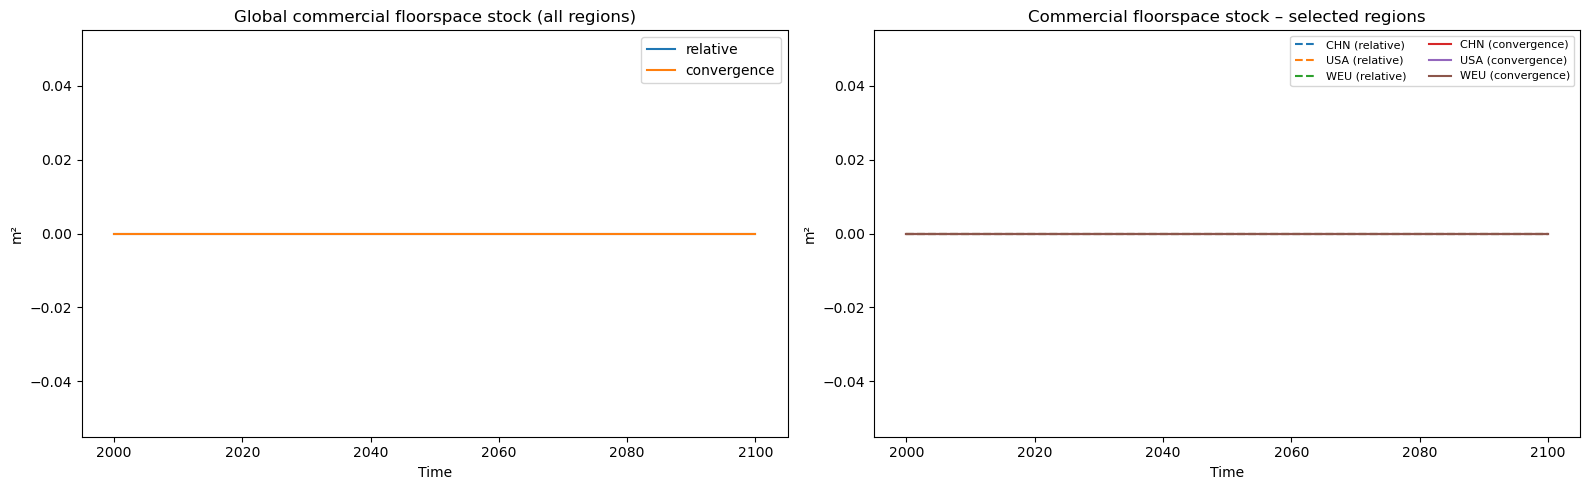

In [3]:

# --- Plot 1: Global total commercial floorspace (all regions summed) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for mode, stocks in results.items():
    total = stocks.sum("Region").loc[2000:]
    if prism.U_(total) is not None:
        total = total.pint.to("m**2")
    total.plot(ax=axes[0], label=mode)
axes[0].set_title("Global commercial floorspace stock (all regions)")
axes[0].set_ylabel("m²")
axes[0].legend()

# --- Plot 2: Per-region comparison for a few selected regions ---
sample_regions = ["CHN", "USA", "IND", "WEU"]
available = [r for r in sample_regions if r in results["relative"].coords["Region"].values]

for mode, stocks in results.items():
    for reg in available:
        series = stocks.sel(Region=reg).loc[2000:]
        if prism.U_(series) is not None:
            series = series.pint.to("m**2")
        linestyle = "-" if mode == "convergence" else "--"
        series.plot(ax=axes[1], label=f"{reg} ({mode})", linestyle=linestyle)
axes[1].set_title("Commercial floorspace stock – selected regions")
axes[1].set_ylabel("m²")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\Lib\site-packages\numpy\lib\_function_base_impl.py:2642: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users

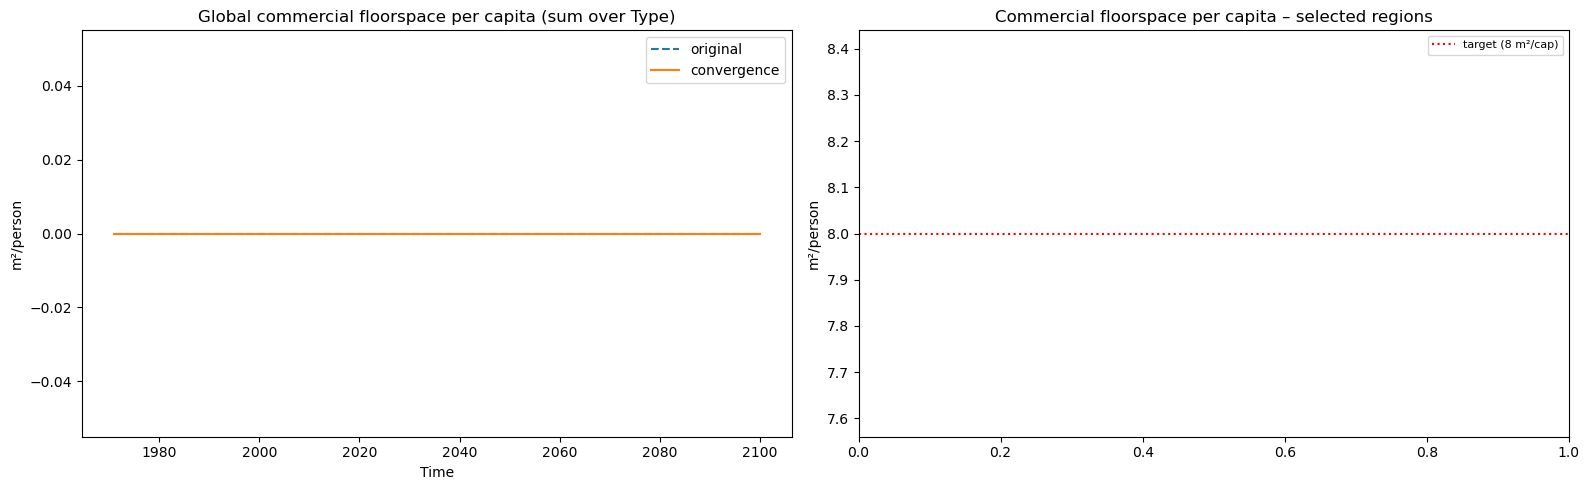


Computed pct_change (convergence target vs start):


In [4]:
import xarray as xr
from imagematerials.util import apply_change_per_region
from imagematerials.buildings.preprocessing.floorspace import (
    get_image_floorspace, extrapolate_floorspace,
)

# --- Get the raw commercial floorspace (before any CE adjustments) ---
image_dir = Path(climate_cfg["config_file_path"])
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    floorspace_image, minimum_comm = get_image_floorspace(image_dir, base_dir)
    floorspace_all = extrapolate_floorspace(floorspace_image, minimum_comm)

comm_types_test = ["Office", "Retail+", "Hotels+", "Govt+"]
floorspace_commercial = floorspace_all.sel(
    Type=[t for t in floorspace_all.coords["Type"].values if t not in ("Urban", "Rural")]
)

# --- Apply the convergence logic directly ---
convergence_year_start = 2025
convergence_year_end = 2100
convergence_target_val = 8.0  # m²/person
implementation_rate = "linear"

total_at_start = floorspace_commercial.sel(Time=convergence_year_start).sum(dim="Type")
conv_target = prism.Q_(convergence_target_val, prism.U_(total_at_start)) \
    if prism.U_(total_at_start) is not None else convergence_target_val

pct_change = ((conv_target - total_at_start) / total_at_start) * 100
pct_change = xr.where(np.isfinite(pct_change), pct_change, 0)

floorspace_converged = apply_change_per_region(
    floorspace_commercial, convergence_year_start, convergence_year_end,
    pct_change, implementation_rate,
)

# --- Compare: original vs converged (sum over Type, per-capita) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_regions = ["CHN", "USA", "INDIA", "WEU"]
available = [r for r in sample_regions
             if r in floorspace_commercial.coords["Region"].values]

# Left: global total
orig_global = floorspace_commercial.sum(["Region", "Type"]).loc[1971:]
conv_global = floorspace_converged.sum(["Region", "Type"]).loc[1971:]
orig_global.plot(ax=axes[0], label="original", linestyle="--")
conv_global.plot(ax=axes[0], label="convergence")
axes[0].set_title("Global commercial floorspace per capita (sum over Type)")
axes[0].set_ylabel("m²/person")
axes[0].legend()

# Right: selected regions
for reg in available:
    orig_r = floorspace_commercial.sel(Region=reg).sum("Type").loc[1971:]
    conv_r = floorspace_converged.sel(Region=reg).sum("Type").loc[1971:]
    orig_r.plot(ax=axes[1], label=f"{reg} (original)", linestyle="--")
    conv_r.plot(ax=axes[1], label=f"{reg} (convergence)")
axes[1].axhline(y=convergence_target_val, color="red", linestyle=":", label="target (8 m²/cap)")
axes[1].set_title("Commercial floorspace per capita – selected regions")
axes[1].set_ylabel("m²/person")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Print the pct_change for a few regions
print("\nComputed pct_change (convergence target vs start):")
for reg in available:
    val = float(pct_change.sel(Region=reg).values)
    start_val = float(total_at_start.sel(Region=reg).values)
    print(f"  {reg}: start={start_val:.2f} m²/cap, pct_change={val:.1f}%")